# Experiment 3.0.1 — Single-$\tau_{syn}$ × objective comparison

## Question
At a fixed 3-layer feature SNN, which homogeneous synaptic time scale is best, and does the answer depend on the training objective?

Backbone: `30 -> 128 -> 128 -> 64`, no recurrence, no bias in SNN linear layers. L1/L2/L3 use the same `shift_syn` within one run. Sweep shifts `[2,3,4,5,6,7]`.

Objectives:
- `timestep_ce`: shared `64 -> 12` classifier at every valid timestep; CE averaged over valid timesteps.
- `relative10_sequence_ce`: valid gesture divided into 10 relative bins; L3 spike counts are flattened and classified once per segment.
- `fixed250_sequence_ce`: valid-masked 250 ms bins (16 samples at 64 Hz); L3 spike counts are flattened and classified once per segment. SNN state is not reset at bin boundaries.

Grid: `6 shifts × 3 objectives × 3 seeds = 54 runs`, seeds `(11,23,101)`, split seed `12345`.

## Execution model
Formal training is performed by the Unity Slurm job array `scripts/bash_script/SNN_Bash/run_exp_3_0_1_cpu_array.bash`. Each array task owns one `(shift, objective, seed)` run and writes only its own checkpoint. After all 54 runs finish, `scripts/experiment_3_0_1/02_finalize_experiment.py` combines checkpoints into the CSV artifacts consumed here. This notebook performs analysis and plotting only.

## 1. Load finalized artifacts

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start=None):
    start=(start or Path.cwd()).resolve()
    for p in (start,*start.parents):
        if (p/'snn').is_dir() and (p/'notebooks').is_dir(): return p
    raise FileNotFoundError('writingRing repo root not found')

REPO_ROOT=find_repo_root()
if str(REPO_ROOT) not in sys.path: sys.path.insert(0,str(REPO_ROOT))
from scripts.experiment_3_0_1_single_tau_objectives import EXPERIMENT_ID, EXPECTED_RUNS, SHIFTS, OBJECTIVES, SEEDS, WIDTHS

RESULTS_DIR=REPO_ROOT/'notebooks/artifacts'/EXPERIMENT_ID
RESULTS_PATH=RESULTS_DIR/'experiment_3_0_1_results.csv'
HISTORY_PATH=RESULTS_DIR/'experiment_3_0_1_history.csv'
SUMMARY_PATH=RESULTS_DIR/'experiment_3_0_1_summary.csv'
missing=[p for p in (RESULTS_PATH,HISTORY_PATH,SUMMARY_PATH) if not p.exists()]
if missing:
    raise FileNotFoundError('Finalized Experiment 3.0.1 artifacts are missing. Run the Slurm array and finalizer first:\n' + '\n'.join(map(str,missing)))
RESULTS=pd.read_csv(RESULTS_PATH)
HISTORY=pd.read_csv(HISTORY_PATH)
SUMMARY=pd.read_csv(SUMMARY_PATH)
if len(RESULTS)!=EXPECTED_RUNS: raise ValueError(f'Expected {EXPECTED_RUNS} runs, found {len(RESULTS)}')
print('Repository root:',REPO_ROOT)
print('Experiment:',EXPERIMENT_ID)
print('Widths:',WIDTHS)
print('Shifts:',SHIFTS)
print('Objectives:',OBJECTIVES)
print('Seeds:',SEEDS)
print('Completed runs:',len(RESULTS),'/',EXPECTED_RUNS)
display(SUMMARY)

Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
Experiment: experiment_3_0_1_single_tau_objective_comparison
Widths: (128, 128, 64)
Shifts: (2, 3, 4, 5, 6, 7)
Objectives: ('timestep_ce', 'relative10_sequence_ce', 'fixed250_sequence_ce')
Seeds: (11, 23, 101)
Completed runs: 54 / 54


,objective,shift,tau_syn_ms,mean_test_balanced_accuracy,mean_test_macro_f1,mean_test_accuracy,mean_probe_test_balanced_accuracy,mean_probe_test_macro_f1,mean_val_balanced_accuracy,mean_train_test_ba_gap,...,sd_test_macro_f1,sd_test_accuracy,sd_probe_test_balanced_accuracy,sd_probe_test_macro_f1,sd_val_balanced_accuracy,sd_train_test_ba_gap,sd_best_epoch,sd_test_l1_firing_rate,sd_test_l2_firing_rate,sd_test_l3_firing_rate
0,fixed250_sequence_ce,2,54.313430,0.305900,0.293312,0.307246,0.335446,0.337758,0.585506,0.620754,...,0.070148,0.069746,0.049985,0.054030,0.035003,0.061373,2.886751,0.000370,0.002569,0.006496
1,fixed250_sequence_ce,3,117.013683,0.380664,0.382985,0.376812,0.401531,0.410915,0.688053,0.597471,...,0.030019,0.030538,0.008265,0.013736,0.028409,0.028695,1.732051,0.000943,0.007137,0.006179
2,fixed250_sequence_ce,4,242.103471,0.373922,0.377671,0.391304,0.394605,0.404733,0.529570,0.603861,...,0.056100,0.048415,0.038048,0.042121,0.050856,0.052680,11.372481,0.000810,0.014749,0.019154
3,fixed250_sequence_ce,5,492.146161,0.307247,0.294162,0.313043,0.305183,0.300168,0.407712,0.595568,...,0.079878,0.069565,0.052118,0.045566,0.013944,0.068482,4.509250,0.006879,0.041222,0.012103
4,fixed250_sequence_ce,6,992.166994,0.277529,0.271960,0.289855,0.308181,0.303504,0.364634,0.588750,...,0.021771,0.020082,0.005967,0.003629,0.023622,0.158683,44.970361,0.002996,0.009563,0.026556
5,fixed250_sequence_ce,7,1992.177288,0.277974,0.265274,0.286957,0.261356,0.239698,0.364061,0.698350,...,0.005433,0.023007,0.037764,0.039876,0.035541,0.037022,36.692415,0.000351,0.014555,0.017387
6,relative10_sequence_ce,2,54.313430,0.478844,0.474315,0.475362,0.320270,0.306699,0.704654,0.469298,...,0.032574,0.027953,0.030108,0.033335,0.037628,0.046564,0.577350,0.000410,0.002112,0.003974
7,relative10_sequence_ce,3,117.013683,0.533353,0.529347,0.524638,0.413252,0.406369,0.725371,0.438690,...,0.021449,0.026566,0.049842,0.035625,0.032369,0.032704,14.640128,0.000643,0.011373,0.041800
8,relative10_sequence_ce,4,242.103471,0.387025,0.381618,0.385507,0.340440,0.337388,0.585977,0.580292,...,0.025350,0.021884,0.007765,0.008932,0.019561,0.021046,14.106736,0.001316,0.011761,0.011758
9,relative10_sequence_ce,5,492.146161,0.309420,0.301598,0.321739,0.305952,0.311926,0.422717,0.678310,...,0.075103,0.052894,0.033256,0.032637,0.040102,0.068859,20.816660,0.005998,0.039346,0.040391


## 2. Per-run metrics

In [2]:
cols=['objective','shift','tau_syn_ms','seed','best_epoch','train_balanced_accuracy','val_balanced_accuracy','test_balanced_accuracy','test_macro_f1','test_accuracy','probe_test_balanced_accuracy','train_test_ba_gap']
display(RESULTS[cols].sort_values(['objective','shift','seed']))

,objective,shift,tau_syn_ms,seed,best_epoch,train_balanced_accuracy,val_balanced_accuracy,test_balanced_accuracy,test_macro_f1,test_accuracy,probe_test_balanced_accuracy,train_test_ba_gap
0,fixed250_sequence_ce,2,54.313430,11,98,0.931972,0.578968,0.315296,0.322596,0.313043,0.362470,0.616676
1,fixed250_sequence_ce,2,54.313430,23,98,0.930101,0.554233,0.368579,0.344073,0.373913,0.366101,0.561522
2,fixed250_sequence_ce,2,54.313430,101,93,0.917891,0.623316,0.233826,0.213266,0.234783,0.277766,0.684064
3,fixed250_sequence_ce,3,117.013683,11,86,0.982995,0.713811,0.383646,0.390336,0.373913,0.397715,0.599349
4,fixed250_sequence_ce,3,117.013683,23,83,0.973162,0.692767,0.405279,0.408646,0.408696,0.411015,0.567883
5,fixed250_sequence_ce,3,117.013683,101,86,0.978247,0.657582,0.353066,0.349973,0.347826,0.395863,0.625180
6,fixed250_sequence_ce,4,242.103471,11,81,0.982006,0.560366,0.327934,0.329285,0.347826,0.394348,0.654072
7,fixed250_sequence_ce,4,242.103471,23,75,0.972586,0.557474,0.364093,0.364565,0.382609,0.356686,0.608493
8,fixed250_sequence_ce,4,242.103471,101,97,0.978755,0.470869,0.429738,0.439165,0.443478,0.432780,0.549017
9,fixed250_sequence_ce,5,492.146161,11,22,0.951896,0.414340,0.303824,0.301161,0.313043,0.261400,0.648072


## 3. Native test balanced accuracy vs shift

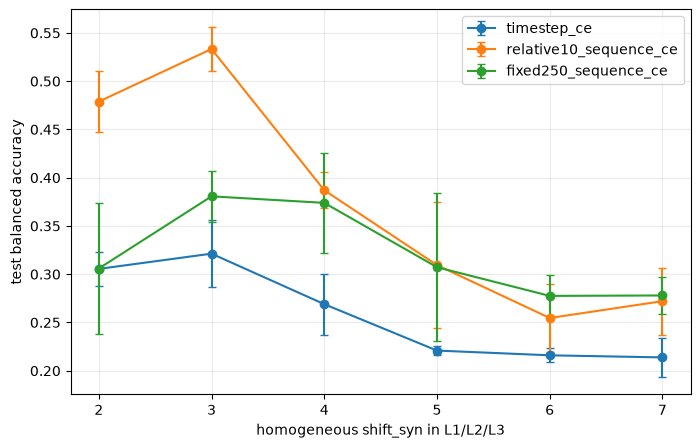

In [3]:
fig,ax=plt.subplots(figsize=(8,5))
for obj in OBJECTIVES:
    p=SUMMARY[SUMMARY.objective==obj].sort_values('shift')
    ax.errorbar(p['shift'],p['mean_test_balanced_accuracy'],yerr=p['sd_test_balanced_accuracy'],marker='o',capsize=3,label=obj)
ax.set(xlabel='homogeneous shift_syn in L1/L2/L3',ylabel='test balanced accuracy',xticks=SHIFTS)
ax.grid(alpha=.25); ax.legend(); plt.show()

## 4. Common fixed-250-ms frozen linear-probe BA

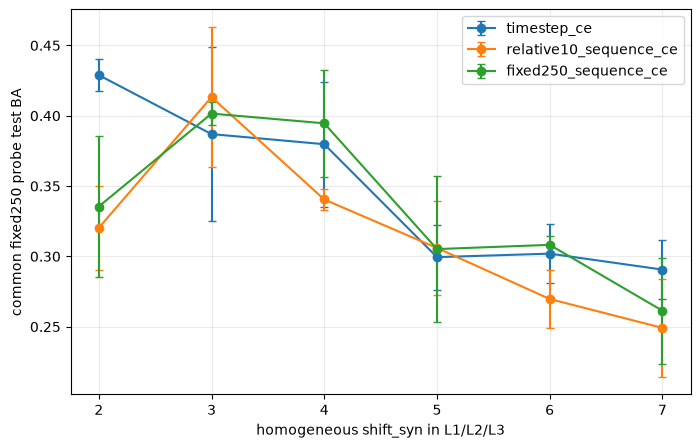

In [4]:
fig,ax=plt.subplots(figsize=(8,5))
for obj in OBJECTIVES:
    p=SUMMARY[SUMMARY.objective==obj].sort_values('shift')
    ax.errorbar(p['shift'],p['mean_probe_test_balanced_accuracy'],yerr=p['sd_probe_test_balanced_accuracy'],marker='o',capsize=3,label=obj)
ax.set(xlabel='homogeneous shift_syn in L1/L2/L3',ylabel='common fixed250 probe test BA',xticks=SHIFTS)
ax.grid(alpha=.25); ax.legend(); plt.show()

## 5. Validation BA vs epoch

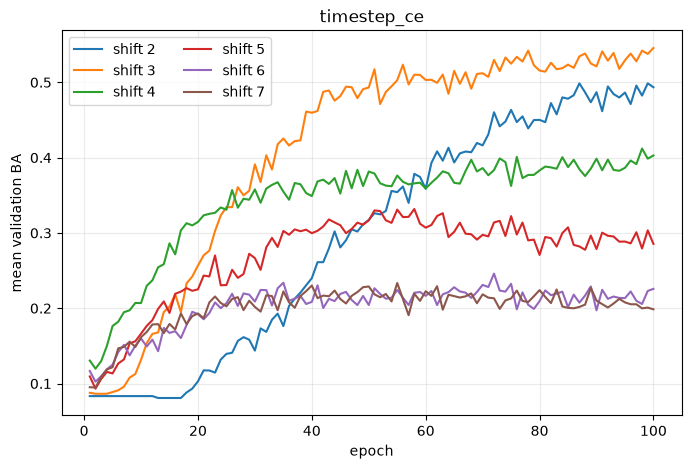

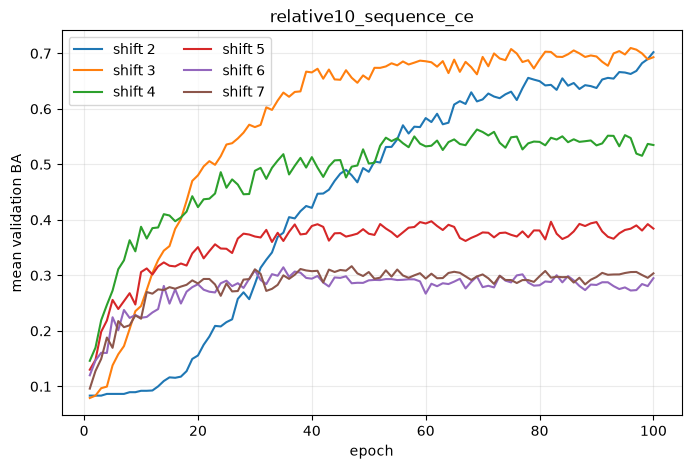

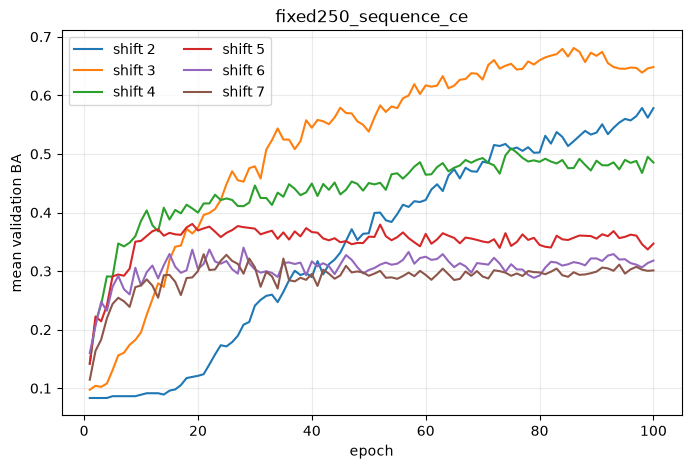

In [5]:
M=HISTORY.groupby(['objective','shift','epoch'],as_index=False).val_balanced_accuracy.mean()
for obj in OBJECTIVES:
    fig,ax=plt.subplots(figsize=(8,5)); p=M[M.objective==obj]
    for shift in SHIFTS:
        q=p[p['shift']==shift]; ax.plot(q.epoch,q.val_balanced_accuracy,label=f'shift {shift}')
    ax.set(title=obj,xlabel='epoch',ylabel='mean validation BA'); ax.grid(alpha=.25); ax.legend(ncol=2); plt.show()

## 6. Firing-rate diagnostics

,objective,shift,seed,test_l1_firing_rate,test_l2_firing_rate,test_l3_firing_rate,zero_l1_firing_rate,zero_l2_firing_rate,zero_l3_firing_rate
0,fixed250_sequence_ce,2,11,0.003180,0.019972,0.072925,0.0,0.0,0.0
1,fixed250_sequence_ce,2,23,0.003017,0.020003,0.060610,0.0,0.0,0.0
2,fixed250_sequence_ce,2,101,0.003725,0.024437,0.070353,0.0,0.0,0.0
3,fixed250_sequence_ce,3,11,0.009285,0.059041,0.176058,0.0,0.0,0.0
4,fixed250_sequence_ce,3,23,0.007419,0.044910,0.164225,0.0,0.0,0.0
5,fixed250_sequence_ce,3,101,0.008113,0.053722,0.167052,0.0,0.0,0.0
6,fixed250_sequence_ce,4,11,0.011411,0.070508,0.225210,0.0,0.0,0.0
7,fixed250_sequence_ce,4,23,0.010383,0.053634,0.188975,0.0,0.0,0.0
8,fixed250_sequence_ce,4,101,0.009812,0.083024,0.196327,0.0,0.0,0.0
9,fixed250_sequence_ce,5,11,0.013079,0.130209,0.256071,0.0,0.0,0.0


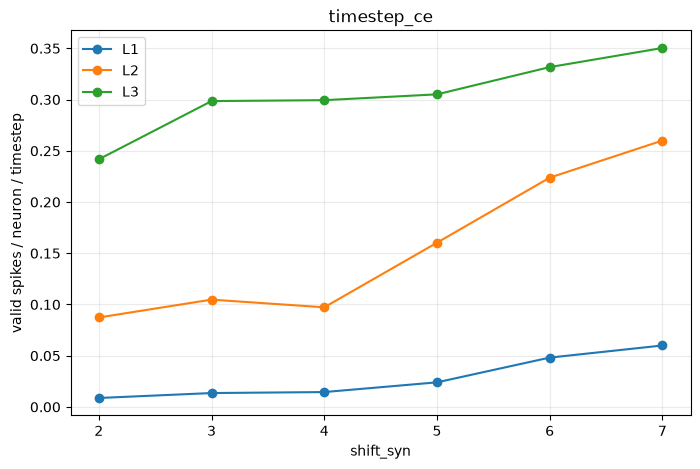

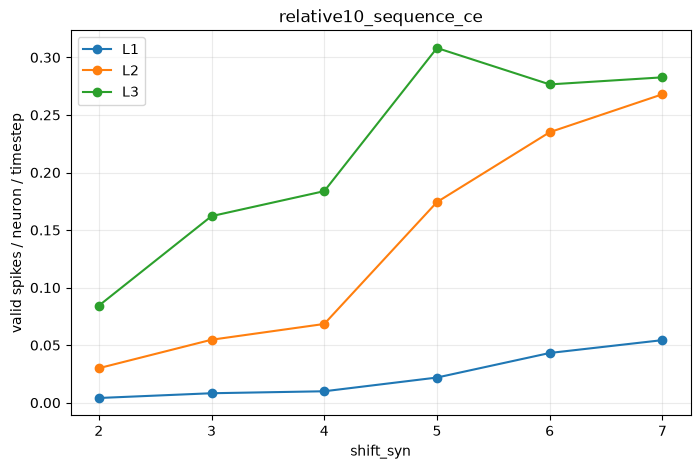

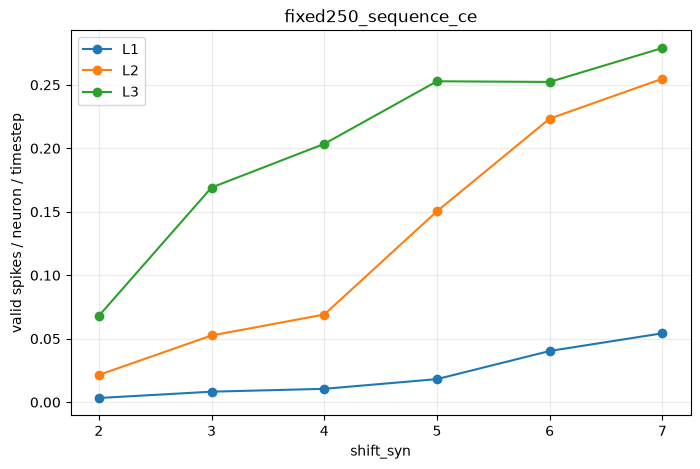

In [6]:
fr_cols=['objective','shift','seed','test_l1_firing_rate','test_l2_firing_rate','test_l3_firing_rate','zero_l1_firing_rate','zero_l2_firing_rate','zero_l3_firing_rate']
display(RESULTS[fr_cols])
for obj in OBJECTIVES:
    fig,ax=plt.subplots(figsize=(8,5))
    p=RESULTS[RESULTS.objective==obj].groupby('shift',as_index=False)[['test_l1_firing_rate','test_l2_firing_rate','test_l3_firing_rate']].mean()
    for col,label in [('test_l1_firing_rate','L1'),('test_l2_firing_rate','L2'),('test_l3_firing_rate','L3')]: ax.plot(p['shift'],p[col],marker='o',label=label)
    ax.set(title=obj,xlabel='shift_syn',ylabel='valid spikes / neuron / timestep',xticks=SHIFTS); ax.grid(alpha=.25); ax.legend(); plt.show()

## 7. Final rankings

In [7]:
native=RESULTS.groupby(['objective','shift']).test_balanced_accuracy.agg(['mean','std']).sort_values('mean',ascending=False)
probe=RESULTS.groupby(['objective','shift']).probe_test_balanced_accuracy.agg(['mean','std']).sort_values('mean',ascending=False)
print('Native head ranking'); display(native)
print('Common frozen-probe ranking'); display(probe)

Native head ranking


mean       std
objective              shift                    
relative10_sequence_ce 3      0.533353  0.022780
                       2      0.478844  0.031988
                       4      0.387025  0.018842
fixed250_sequence_ce   3      0.380664  0.026234
                       4      0.373922  0.051609
timestep_ce            3      0.321288  0.035059
relative10_sequence_ce 5      0.309420  0.065463
fixed250_sequence_ce   5      0.307247  0.076440
                       2      0.305900  0.067866
timestep_ce            2      0.305503  0.017614
fixed250_sequence_ce   7      0.277974  0.019386
                       6      0.277529  0.022133
relative10_sequence_ce 7      0.272058  0.034599
timestep_ce            4      0.268959  0.031684
relative10_sequence_ce 6      0.254622  0.034930
timestep_ce            5      0.220871  0.004557
                       6      0.215969  0.007418
                       7      0.213797  0.020302

Common frozen-probe ranking


mean       std
objective              shift                    
timestep_ce            2      0.428884  0.011239
relative10_sequence_ce 3      0.413252  0.049842
fixed250_sequence_ce   3      0.401531  0.008265
                       4      0.394605  0.038048
timestep_ce            3      0.386937  0.062033
                       4      0.379758  0.044464
relative10_sequence_ce 4      0.340440  0.007765
fixed250_sequence_ce   2      0.335446  0.049985
relative10_sequence_ce 2      0.320270  0.030108
fixed250_sequence_ce   6      0.308181  0.005967
relative10_sequence_ce 5      0.305952  0.033256
fixed250_sequence_ce   5      0.305183  0.052118
timestep_ce            6      0.301928  0.021090
                       5      0.299443  0.023149
                       7      0.290588  0.021117
relative10_sequence_ce 6      0.269685  0.020293
fixed250_sequence_ce   7      0.261356  0.037764
relative10_sequence_ce 7      0.249122  0.034903

## Interpretation
Use the three-seed mean and SD rather than any single run. First determine whether a consistent single-$\tau$ optimum exists. Then test whether that optimum changes across supervision objectives. Compare native-head BA with the common fixed250 frozen probe: agreement supports a representation-level effect, while disagreement suggests the training/readout head contributes materially. Inspect firing rates and train–test gap before selecting the single-$\tau$ baseline for the subsequent multi-$\tau$ architecture study.